In [1]:
import numpy as np
import pandas as pd
import os, sys, glob, shutil 
from config import *
from plotting_functions import *
import analysis_helpers as helper
sys.path.insert(0,'../..')
%load_ext autoreload
%autoreload 2
%matplotlib inline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, scipy
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import inspect
from scipy.spatial.distance import pdist, cdist,squareform
from scipy.stats import zscore, wasserstein_distance, ttest_1samp, percentileofscore,ttest_rel, ttest_ind, sem,f_oneway, spearmanr, pearsonr
from sklearn.decomposition import PCA, FactorAnalysis
import matplotlib as mpl
from TPHATE.tphate import tphate
import scprep
import nibabel as nib
from nilearn.maskers import NiftiMasker
from nibabel import Nifti1Image
from nilearn import plotting,image  
import matplotlib 
matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams["pdf.use14corefonts"] = True
sns.set_context(context_params)
plt.rcParams.update({
    'font.size': 10,           # Default text size
    'axes.titlesize': 12,      # Axes title
    'axes.labelsize': 12,      # Axes labels
    'xtick.labelsize': 8,     # X tick labels
    'ytick.labelsize': 8,     # Y tick labels
    'legend.fontsize': 11,     # Legend
    'figure.titlesize': 14     # Figure title
})

In [3]:
cumulative_info = helper.load_info_file()
main_results = pd.read_csv('results/final_results/evr_bc_final.csv')
main_results.head()

,Unnamed: 0,session_type,session_number,delta_EVR,delta_BC,subject_id
0,0,IM,2,0.035580,0.40,avatarRT_sub_05
1,1,WMP,3,0.050398,0.56,avatarRT_sub_05
2,2,OMP,4,0.004348,-0.24,avatarRT_sub_05
3,3,IM,2,-0.005052,0.36,avatarRT_sub_06
4,4,WMP,4,-0.009034,0.20,avatarRT_sub_06


In [22]:
df1 = pd.DataFrame(columns=['subject_id','session_number','session_type','score','metric','n_voxels','wmp_first'])
for sub in main_results.subject_id:
    mask = nib.load(f'{DATA_PATH}/{subject}/reference/mask.nii.gz').get_fdata()
    tot_vox = np.sum(mask)

    for t in ['IM','WMP','OMP']:
        row = main_results[(main_results['session_type']==t)&(main_results['subject_id']==sub)]
        df1.loc[len(df1)] = {'subject_id':sub, 
                             'session_number':row.session_number.item(), 
                             'session_type':t,
                            'score':row.delta_EVR.item(),
                            'metric':'delta_EVR',
                            'n_voxels':tot_vox,
                            'wmp_first':sub in WM_FIRST}
        df1.loc[len(df1)] = {'subject_id':sub, 
                             'session_number':row.session_number.item(), 
                             'session_type':t,
                            'score':row.delta_BC.item(),
                            'metric':'delta_BC',
                            'n_voxels':tot_vox,
                            'wmp_first':sub in WM_FIRST}
        


In [23]:
df1.to_csv('results/results_public/main_results.csv')

In [65]:
def bootstrap_spearman_ci(x, y, n_bootstrap=1000, ci=95, random_state=4):
    n = len(x)
    rng = np.random.default_rng(random_state)
    boot_corrs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        boot_corrs[i] = spearmanr(x[idx], y[idx])[0]
    lower = np.percentile(boot_corrs, (100 - ci) / 2)
    upper = np.percentile(boot_corrs, 100 - (100 - ci) / 2)
    return np.mean(boot_corrs), (lower, upper), spearmanr(x,y)[1]


def plot_rhos_with_cis(rhos, lowers, uppers, labels=None, color='C0', ax=None, ylabel='Correlation (rho)'):
    """
    Plot multiple bars for rhos with error bars for confidence intervals.

    Parameters
    ----------
    rhos : array-like
        Heights of the bars (e.g., correlation coefficients), shape (n,)
    lowers : array-like
        Lower bounds of the confidence intervals, shape (n,)
    uppers : array-like
        Upper bounds of the confidence intervals, shape (n,)
    labels : list of str or None
        Labels for each bar (x-tick labels).
    color : str or array-like
        Color or list of colors for the bars.
    ax : matplotlib.axes.Axes or None
        Axis to plot on. If None, creates a new figure.
    ylabel : str
        Label for the y-axis.
    """
    rhos = np.asarray(rhos)
    lowers = np.asarray(lowers)
    uppers = np.asarray(uppers)
    n = len(rhos)
    x = np.arange(n)
    if ax is None:
        fig, ax = plt.subplots()
    # Error bars: distance from mean to bounds
    yerr = np.vstack([rhos - lowers, uppers - rhos])
    ax.bar(x, rhos, yerr=yerr, color=color, capsize=0, lw=2, ec='k')
    if labels is not None:
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
    else:
        ax.set_xticks(x)
        ax.set_xticklabels([f'Bar {i+1}' for i in x])
    ax.set_ylabel(ylabel)
    ax.axhline(0, ls='--', c='k') 
    ax.set_ylim((-1,1))
    plt.tight_layout()
    return ax

# Run eigenspectrum for each subject

In [31]:
def tiny_to_sci(x, precision=2):
    import numpy as np
    if np.isscalar(x):
        return f"{x:.{precision}e}"
    else:
        return [f"{val:.{precision}e}" for val in np.asarray(x)]



def plot_scree_grid_shared_axes(file_list, nrows=4, ncols=5, figsize=(16, 10), titles=None):
    """
    Plot scree plots (eigenvalues) for each file in a grid using seaborn.
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()
    for i, fname in enumerate(file_list):
        try:
            data = np.load(fname)
        except Exception:
            data = np.loadtxt(fname, delimiter=',')
        cov = np.cov(data, rowvar=False)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.sort(eigvals)[::-1]
        ax = axes[i]
        sns.lineplot(x=np.arange(1, len(eigvals)+1), y=eigvals, marker='o', ax=ax, color='C1')
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=10)
        else:
            ax.set_title(f'File {i+1}', fontsize=10)
        if i % ncols == 0:
            ax.set_ylabel('Eigenvalue')
        if i >= (nrows-1)*ncols:
            ax.set_xlabel('Component')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: tiny_to_sci(y, 1)))
        sns.despine(ax=ax)
    for j in range(len(file_list), nrows*ncols):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
    
def plot_variance_explained_all_subjects(file_list, subject_labels=None):
    """
    For each file (subject), estimate % variance explained by each component,
    then plot all subjects together: x=component, y=%variance explained,
    each subject is a line across components.
    """
    all_var_expl = []
    min_components = None
    # Load and compute variance explained for each subject
    for fname in file_list:
        try:
            data = np.load(fname)
        except Exception:
            data = np.loadtxt(fname, delimiter=',')
        cov = np.cov(data, rowvar=False)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.sort(eigvals)[::-1]
        var_explained = eigvals / eigvals.sum() * 100
        all_var_expl.append(var_explained)
        if min_components is None or len(var_explained) < min_components:
            min_components = len(var_explained)
    # Truncate to minimum number of components across all files
    all_var_expl = np.array([v[:min_components] for v in all_var_expl])
    n_subjects = all_var_expl.shape[0]
    x = np.arange(1, min_components+1)
    fig,ax=plt.subplots(1,1,figsize=(8, 6))
    for i in range(n_subjects):
        label = subject_labels[i] if subject_labels is not None else f"Subject {i+1}"
#        sns.lineplot(x=x, y=all_var_expl[i], marker='o', alpha=0.7, label=label, ax=ax)
    sns.lineplot(all_var_expl.T,ax=ax)
    plt.xlabel('Component')
    plt.ylabel('% Variance Explained')
    plt.title('Variance Explained by Component Across Subjects')
    plt.xticks(x)
    # plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: tiny_to_sci(y, 2)))
    sns.despine()
    plt.tight_layout()
    # Optionally, show legend if you want to see subject IDs
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.show()

def plot_variance_explained_grid(file_list, nrows=3, ncols=6, special_idx=[1,2,20], excl_idx=[4,14], figsize=(16, 10), titles=None, outfn=''):
    """
    Plot % variance explained by each component for each file in a grid using seaborn.
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()
    var_explaineds=[]
    file_list = [file_list[i] for i in range(len(file_list)) if i not in excl_idx]
    titles = [titles[i] for i in range(len(titles)) if i not in excl_idx]
                                           
    for i, fname in enumerate(file_list):
        data = np.load(fname)
        cov = np.cov(data, rowvar=False)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.sort(eigvals)[::-1]
        var_explained = eigvals / eigvals.sum() * 100
        ax = axes[i]
        g=sns.lineplot(x=np.arange(1, len(var_explained)+1), y=var_explained, ax=ax, color='C0',marker='o')
        y=[var_explained[s-1] for s in special_idx]
        g=sns.scatterplot(x=special_idx, y=y, color='red', marker='x', s=80, zorder=10, ax=ax)
        # yticklabels=[0,20,40]
        
        if titles is not None and i < len(titles):
            g.set_title(titles[i], fontsize=14)
        else:
            g.set_title(f'File {i+1}', fontsize=10)
        if i % ncols == 0:
            g.set_ylabel('% Variance Explained',fontsize=12)
            # g.set_yticklabels(yticklabels, fontsize=10)
        if i >= (nrows-1)*ncols:
            g.set_xlabel('Component')            
        sns.despine()
        ax.tick_params(axis='y', labelsize=10)  # or any size you prefer
        ax.tick_params(axis='x', labelsize=10)  # or any size you prefer
        var_explaineds.append(var_explained)
        
    # for j in range(len(file_list), nrows*ncols):
    #     axes[j].axis('off')
    plt.tight_layout()
    if len(outfn) > 0:
        plt.savefig(outfn, format='pdf', transparent=True)
    return np.array(var_explaineds)

In [26]:
file_list = [f'{DATA_PATH}/{S}/model/bottleneck.npy' for S in SUB_IDS]
df_runchange=pd.read_csv('./results/final_results/runwise_component_EVR_neural_analysis_run_change.csv')
df_runchange_cong = df_runchange[df_runchange['congruent']==True]
sub_excl = np.setdiff1d(SUB_IDS, ['avatarRT_sub_09', 'avatarRT_sub_20'])
df_runchange_cong = df_runchange_cong[df_runchange_cong['subject_id'].isin(sub_excl)].reset_index(drop=True)

run_results=pd.read_csv(BEHAV_SESSION_RES,index_col=0)
run_results=run_results[run_results['subject_id'].isin(sub_excl)].reset_index(drop=True)


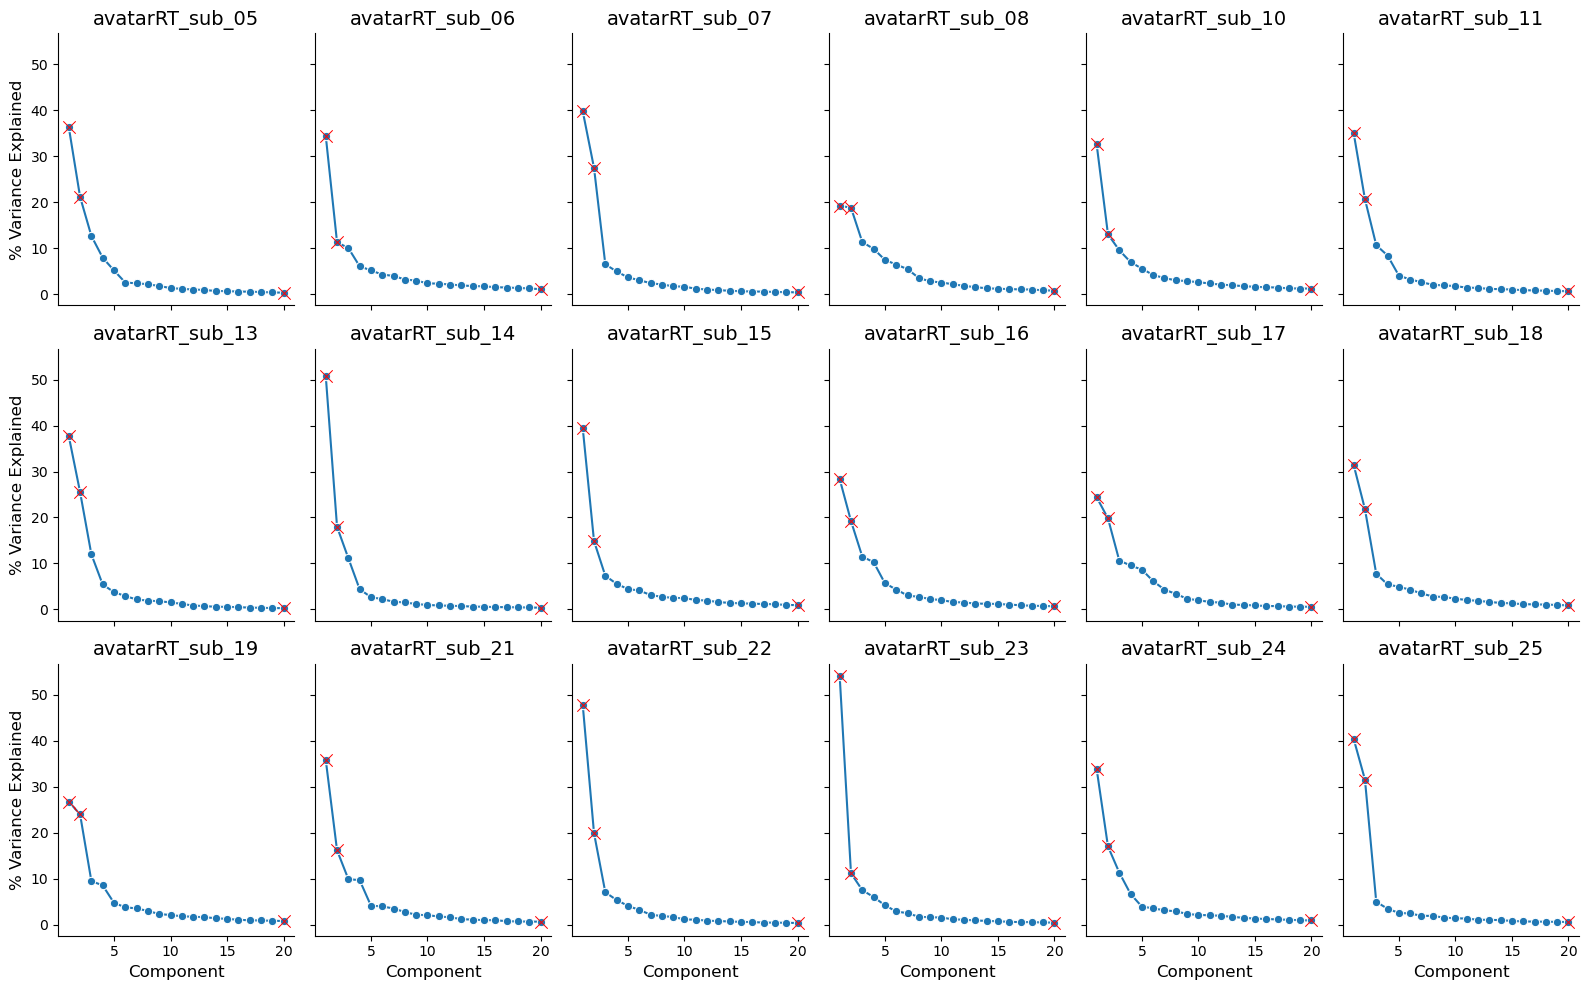

In [33]:
V = plot_variance_explained_grid(file_list, titles=SUB_IDS, outfn='revision_plots/control_space_eigenspectrum.pdf')

In [34]:
V.shape

(18, 20)

In [35]:
df1 = pd.DataFrame(columns=['subject_id','component_idx','PEV_initial','nfb_condition'])
for j,s in enumerate(sub_excl):
    for i in range(20):
        if i == 0:
            comp = 'IM'
        elif i == 1:
            comp = 'WMP'
        elif i == 19:
            comp = 'OMP'
        else:
            comp='untrained'
        df1.loc[len(df1)] = {'subject_id':s, 'componet_idx':i, 'PEV_initial':V[j,i], 'nfb_condition':comp}
df1.to_csv('results/results_public/manifold_eigenspectrum.csv')
        

In [47]:
df1=helper.extract_data_from_df(df_runchange_cong, ['session_type'], ['WMP'])
beh_wmp=helper.extract_data_from_df(run_results, ['session_type'], ['WMP'])['delta_BC'].values
beh_im=helper.extract_data_from_df(run_results, ['session_type'], ['IM'])['delta_BC'].values

evr_im = helper.extract_data_from_df(df_runchange_cong, ['session_type'], ['IM'])['delta_run_perturb'].values
evr_wmp = helper.extract_data_from_df(df_runchange_cong, ['session_type'], ['WMP'])['delta_run_perturb'].values


df1['delta_bc_WMP'] = beh_wmp
df1['perc_var_exp_initial'] = [v[1] for v in V]
df1['delta_varexp_IM_WMP'] = [v[0]-v[1] for v in V]
df1['delta_evr_IM_WMP'] = evr_im - evr_wmp
df1['delta_bc_IM_WMP'] = beh_im - beh_wmp


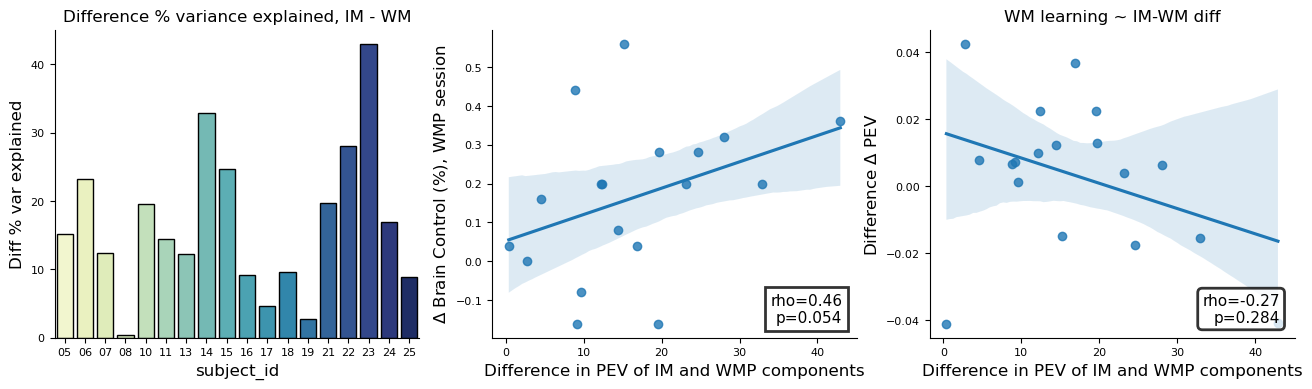

In [61]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
g=sns.barplot(data=df1, x="subject_id", y="delta_varexp_IM_WMP", ax=ax[0], palette='YlGnBu', edgecolor='k', lw=1)
g.set(xticklabels=[v.split('_')[-1] for  v in df1.subject_id.values], ylabel='Diff % var explained', 
      title='Difference % variance explained, IM - WM')


r,p=spearmanr(df1['delta_bc_WMP'],df1['delta_varexp_IM_WMP'])
g=sns.regplot(data=df1, y="delta_bc_WMP", x="delta_varexp_IM_WMP", ax=ax[1])
g.set(xlabel='Difference in PEV of IM and WMP components', 
       ylabel=f'$\Delta$ Brain Control (%), WMP session', 
      title=f'')
# Add text box in lower right
g.text(
    0.96, 0.04, f'rho={np.round(r,2)}\np={np.round(p,3)}',
    transform=g.transAxes,
    fontsize=11,
    va='bottom', ha='right',
    bbox=dict(facecolor='white', alpha=0.8)
)



r,p=spearmanr(df1['delta_evr_IM_WMP'],df1['delta_varexp_IM_WMP'])
g=sns.regplot(data=df1, y="delta_evr_IM_WMP", x="delta_varexp_IM_WMP", ax=ax[2])
g.set(xlabel='Difference in PEV of IM and WMP components', 
       ylabel=r'Difference $\Delta$ PEV', 
      title=f'WM learning ~ IM-WM diff')
# Add text box in lower right
g.text(
    0.96, 0.04, f'rho={np.round(r,2)}\np={np.round(p,3)}',
    transform=g.transAxes,
    fontsize=11,
    va='bottom', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

sns.despine()
# plt.savefig('revision_plots/revions_plot_2_justifier.pdf', format='pdf', transparent=True)

# mask size analysis

In [18]:
nvox=np.zeros(len(main_results))

for subject in main_results.subject_id.unique():
    mask = nib.load(f'{DATA_PATH}/{subject}/reference/mask.nii.gz').get_fdata()
    tot_vox = np.sum(mask)
    idx = main_results[main_results['subject_id']==subject].index.values
    nvox[idx]=tot_vox
    
main_results['n_voxels']=nvox


In [19]:
main_results

,Unnamed: 0,session_type,session_number,delta_EVR,delta_BC,subject_id,n_voxels
0,0,IM,2,0.035580,0.40,avatarRT_sub_05,1408.0
1,1,WMP,3,0.050398,0.56,avatarRT_sub_05,1408.0
2,2,OMP,4,0.004348,-0.24,avatarRT_sub_05,1408.0
3,3,IM,2,-0.005052,0.36,avatarRT_sub_06,1238.0
4,4,WMP,4,-0.009034,0.20,avatarRT_sub_06,1238.0
5,5,OMP,3,0.007410,-0.16,avatarRT_sub_06,1238.0
6,6,IM,2,0.015314,0.56,avatarRT_sub_07,1251.0
7,7,WMP,3,-0.007159,0.20,avatarRT_sub_07,1251.0
8,8,OMP,4,-0.001659,0.04,avatarRT_sub_07,1251.0
9,9,IM,2,-0.000197,0.60,avatarRT_sub_08,1500.0


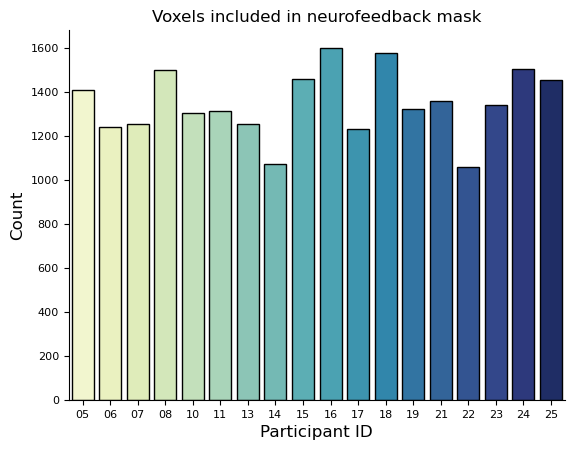

In [68]:
g=sns.barplot(data=main_results[main_results['session_type']=='IM'], x="subject_id", y="n_voxels", palette='YlGnBu', edgecolor='k', lw=1)
g.set(xticklabels=[v.split('_')[-1] for  v in main_results[main_results['session_type']=='IM'].subject_id.values], ylabel='Count', 
      title='Voxels included in neurofeedback mask', xlabel='Participant ID')
sns.despine()
plt.savefig('revision_plots/mask_size.pdf',transparent=True,format='pdf')

mask size ~ bci learning
IM spearman rho: -0.284, 95% CI: [-0.712, 0.221], p=0.23180846026195848
WMP spearman rho: -0.272, 95% CI: [-0.722, 0.250], p=0.27543677056641946
OMP spearman rho: 0.035, 95% CI: [-0.456, 0.478], p=0.8380444427907051
mask size ~ neural learning
IM spearman rho: 0.060, 95% CI: [-0.424, 0.526], p=0.848430360162973
WMP spearman rho: 0.153, 95% CI: [-0.333, 0.605], p=0.5152947310342115
OMP spearman rho: 0.118, 95% CI: [-0.448, 0.625], p=0.5984607651208833


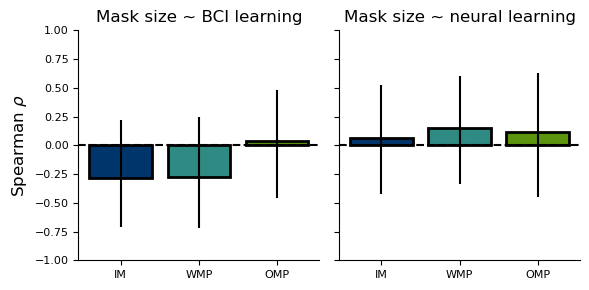

In [71]:
fig,ax=plt.subplots(1,2,figsize=(6,3), sharey=True)
rhos, lowers, uppers = [], [], []
conds = ['IM','WMP','OMP']
print("mask size ~ bci learning")

for cond in ['IM','WMP','OMP']:
    sub_df = helper.extract_data_from_df(main_results, ['session_type'],[cond])
    rho, (ci_low, ci_high), p = bootstrap_spearman_ci(sub_df['n_voxels'].values, sub_df['delta_BC'].values, n_bootstrap=1000, ci=95)

    print(f"{cond} spearman rho: {rho:.3f}, 95% CI: [{ci_low:.3f}, {ci_high:.3f}], p={p}")
    rhos.append(rho)
    lowers.append(ci_low)
    uppers.append(ci_high)

g = plot_rhos_with_cis(rhos, lowers, uppers, labels=conds, 
                       color=[colors_main[c] for c in conds], ax=ax[0], ylabel=r'Spearman $\rho$')
g.set(ylabel=r'Spearman $\rho$', title='Mask size ~ BCI learning')

rhos, lowers, uppers = [], [], []
conds = ['IM','WMP','OMP']
print("mask size ~ neural learning")
for cond in ['IM','WMP','OMP']:
    sub_df = helper.extract_data_from_df(main_results, ['session_type'],[cond])
    rho, (ci_low, ci_high), p = bootstrap_spearman_ci(sub_df['n_voxels'].values, sub_df['delta_EVR'].values, n_bootstrap=1000, ci=95)

    print(f"{cond} spearman rho: {rho:.3f}, 95% CI: [{ci_low:.3f}, {ci_high:.3f}], p={p}")
    rhos.append(rho)
    lowers.append(ci_low)
    uppers.append(ci_high)

    #rhos, lowers, uppers, labels=None, color='C0', ax=None, ylabel='Correlation (rho)')
    
g = plot_rhos_with_cis(rhos, lowers, uppers, labels=conds, 
                       color=[colors_main[c] for c in conds], ax=ax[1], ylabel='')
g.set(title='Mask size ~ neural learning')
sns.despine()
fig.tight_layout()
plt.savefig(f'revision_plots/mask_size_neural_learning.pdf', format='pdf', transparent=True)
    

# order effects

In [27]:
wmp_first = []

for s in main_results.subject_id.unique():
    for i in range(3):
        if s in WM_FIRST:
            wmp_first.append(1)
        else:
            wmp_first.append(0)
main_results['wmp_first']=wmp_first

In [28]:
def annot_pval(p):
    # Annotate p-value
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'n.s.'
    return sig

In [38]:
df = main_results[main_results['session_type']!='IM']

for VAR in ['delta_BC', 'delta_EVR']:
    print("\n" + "="*60)
    print(f"RESULTS FOR {VAR}")
    print("\n" + "="*60)
    print("\n" + "="*60)
    # Overall descriptives
    desc_stats = df.groupby(['session_type', 'wmp_first'])[VAR].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(3)

    # Create summary table for reporting
    summary_table = df.groupby(['session_type', 'wmp_first'])[VAR].agg([
        'mean', 'std', 'count'
    ]).round(3)
    summary_table.columns = ['Mean', 'SD', 'N']

    # Grand means for main effects
    session_means = df.groupby('session_type')[VAR].agg(['mean', 'std', 'count']).round(3)
    group_means = df.groupby('wmp_first')[VAR].agg(['mean', 'std', 'count']).round(3)

    print(session_means)
    # ============================================================================
    # OLS REGRESSION MODEL
    # ============================================================================
    print("\n" + "="*60)
    print("OLS REGRESSION MODEL")
    print("="*60)

    # Fit the OLS model with interaction
    # Note: Using C() to treat variables as categorical
    model = ols(f'{VAR} ~ C(session_type) * C(wmp_first)', data=df)
    result = model.fit()

    print("\nOLS Model Summary:")
    print(result.summary())

    # ============================================================================
    # ANOVA TABLE AND F-TESTS
    # ============================================================================
    print("\n" + "="*60)
    print("ANOVA TABLE AND F-TESTS")
    print("="*60)

    # Perform ANOVA on the OLS model
    anova_table = anova_lm(result, typ=2)  # Type II ANOVA
    print("\nType II ANOVA Results:")
    print(anova_table.round(6))

    # Extract F-statistics and p-values for reporting
    f_session = anova_table.loc['C(session_type)', 'F']
    p_session = anova_table.loc['C(session_type)', 'PR(>F)']
    df_session_num = anova_table.loc['C(session_type)', 'df']
    df_session_den = anova_table.loc['Residual', 'df']

    f_group = anova_table.loc['C(wmp_first)', 'F']
    p_group = anova_table.loc['C(wmp_first)', 'PR(>F)']
    df_group_num = anova_table.loc['C(wmp_first)', 'df']
    df_group_den = anova_table.loc['Residual', 'df']

    f_interaction = anova_table.loc['C(session_type):C(wmp_first)', 'F']
    p_interaction = anova_table.loc['C(session_type):C(wmp_first)', 'PR(>F)']
    df_interaction_num = anova_table.loc['C(session_type):C(wmp_first)', 'df']
    df_interaction_den = anova_table.loc['Residual', 'df']
    # Create summary dictionary
    results_summary = {
        'Main_Effect_Session': {
            'F': f_session,
            'df_num': df_session_num,
            'df_den': df_session_den,
            'p_value': p_session,
            'significant': p_session < 0.05
        },
        'Main_Effect_Group': {
            'F': f_group,
            'df_num': df_group_num,
            'df_den': df_group_den,
            'p_value': p_group,
            'significant': p_group < 0.05
        },
        'Interaction': {
            'F': f_interaction,
            'df_num': df_interaction_num,
            'df_den': df_interaction_den,
            'p_value': p_interaction,
            'significant': p_interaction < 0.05
        },
    }

    print("\nFinal Summary:")
    print(f"Session Type Effect: F({df_session_num:.0f},{df_session_den:.0f}) = {f_session:.2f}, {p_session} ")
    print(f"Group Order Effect: F({df_group_num:.0f},{df_group_den:.0f}) = {f_group:.2f}, {p_group} ")
    print(f"Interaction Effect: F({df_interaction_num:.0f},{df_interaction_den:.0f}) = {f_interaction:.2f}, {p_interaction }")


RESULTS FOR delta_BC


               mean    std  count
session_type                     
OMP          -0.004  0.141     18
WMP           0.164  0.197     18

OLS REGRESSION MODEL

OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:               delta_BC   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     3.600
Date:                Wed, 08 Oct 2025   Prob (F-statistic):             0.0239
Time:                        17:27:37   Log-Likelihood:                 14.576
No. Observations:                  36   AIC:                            -21.15
Df Residuals:                      32   BIC:                            -14.82
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
        

0.0012935733031957798 0.12477101149140647
0.5349039169105604 0.5361560163778698


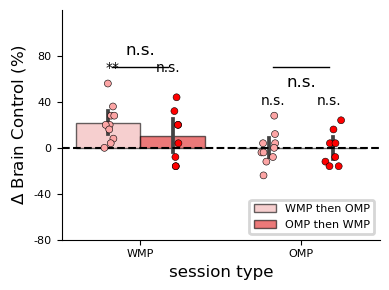

In [125]:
pal = sns.color_palette(["#fca5a5", "#ff0000"]) 
df=run_results[run_results['session_type']!='IM']
fig, ax = plt.subplots(figsize=(4,3))
sns.barplot(data=df, hue='wmp_first', y='delta_BC', order=['WMP','OMP'], x='session_type', 
            hue_order=[1,0], ax=ax,palette=pal,edgecolor='k',linewidth=1,alpha=0.6)

g=sns.stripplot(hue='wmp_first', edgecolor='k',linewidth=0.4, x='session_type', 
                dodge=True, y='delta_BC', palette=pal, order=['WMP','OMP'],jitter=True,
                data=df, legend=False, hue_order=[1,0],
                ax=ax) 

            

# Change legend labels
handles, labels = ax.get_legend_handles_labels()
ax.axhline(0, ls='--', c='k') 

g.set(ylim=[-0.8, 1.2], yticks=np.arange(-0.8, 1.2, 0.4), 
      ylabel=r'$\Delta$ Brain Control (%)',
      yticklabels=np.arange(-80, 100, 40), 
      xlabel='session type', 
      xticklabels=['WMP','OMP'])

# Calculate significance and add bars
x_locs = np.arange(2)
bar_width = 0.35  # default seaborn bar width

for j,i in enumerate(['WMP','OMP']):
    vals0 = df[(df['session_type'] == i) & (df['wmp_first'] == 1)]['delta_BC']
    vals1 = df[(df['session_type'] == i) & (df['wmp_first'] == 0)]['delta_BC']
    
    # Use ttest_rel for paired, ttest_ind for independent
    observed, pvalue = ttest_ind(vals0, vals1, alternative='greater')
    # observed, pvalue, _ = helper.permutation_test(np.array([vals0, vals1]) , 1000, alternative='greater')
    # Bar positions
    x0 = j - bar_width/2
    x1 = j + bar_width/2
    y, h, col = max(vals0.max(), vals1.max()) + 0.1, 0.08, 'k'
    ax.plot([x0, x1], [0.7, 0.7], lw=1, c=col)
    sig=annot_pval(pvalue)
    ax.text(j, y+h+0.04, sig, ha='center', va='bottom', color=col, fontsize=12)
    
    # add over individual bars
    _, p0 = ttest_1samp(vals0, 0, alternative='greater')
    _, p1 = ttest_1samp(vals1, 0, alternative='greater')
    print(p0, p1)
    y, h, col = max(vals0.max(), vals1.max()) + 0.02, 0.03, 'k'
    ax.text(x0, y+h+0.02, annot_pval(p0), ha='center', va='bottom', color=col, fontsize=10)
    ax.text(x1, y+h+0.02, annot_pval(p1), ha='center', va='bottom', color=col, fontsize=10)

ax.legend(handles, ["WMP then OMP", "OMP then WMP"], title="", fontsize=8,loc='lower right' )
sns.despine()
plt.tight_layout()
plt.savefig('revision_plots/session_order.pdf', format='pdf', transparent=True)

# delta PEV analyses

In [63]:
df = pd.read_csv('results/final_results/runwise_component_EVR_neural_analysis_run_change_control.csv', index_col=0)
# exclude subs
df = df[~df['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20'])]

In [65]:
dfc = df[df['congruent']==True]

In [74]:
rr_list = []
for row in run_results.index:
    row = run_results.iloc[row]
    v = dfc[(dfc['subject_id']==row.subject_id) & (dfc['session_type']==row.session_type)].delta_evr_since_perturb.item()
    rr_list.append(v)
dfc['evr']=rr_list

/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [242]:
order=list(df.comparison_component_name.unique()[:-1])
order.insert(2,'OMP')
order=order[:-1]
df['delta_pev_since_perturb']=100*df['delta_evr_since_perturb'].values


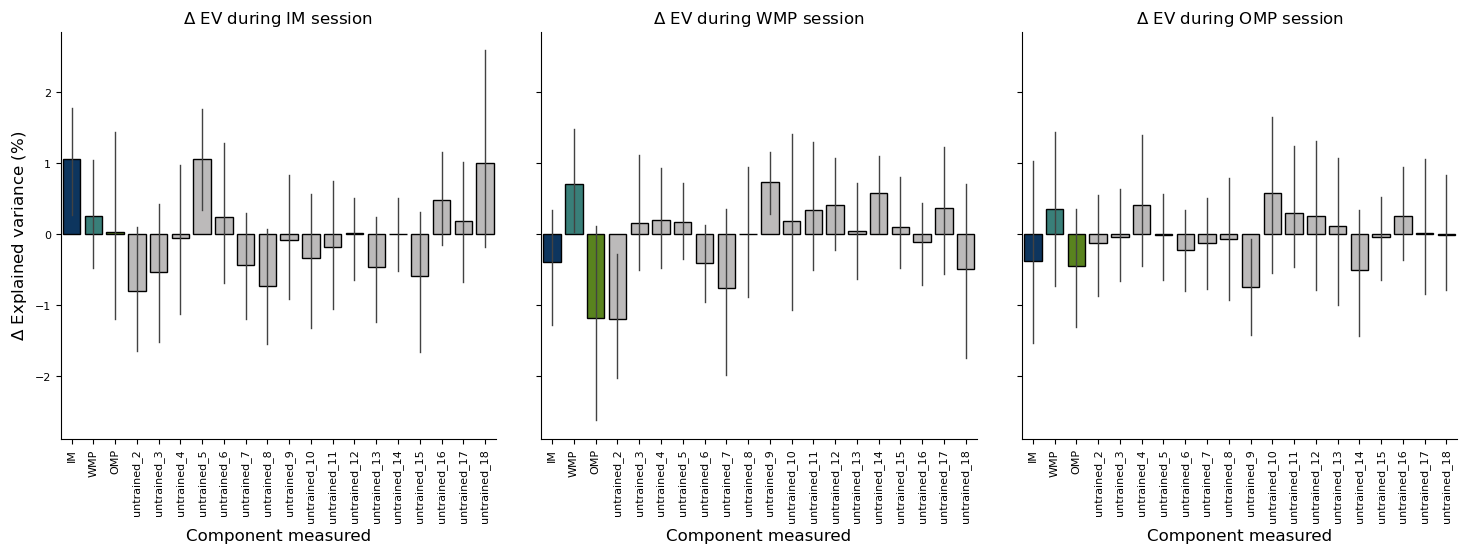

In [253]:
bar_colors = [colors_main[x] if x in xvars else '#bcbabab0' for x in order ]

g=sns.catplot(col='session_type', x='comparison_component_name', 
              y='delta_pev_since_perturb', data=df, 
              kind='bar', edgecolor='k', lw=1, 
              order=order, palette=bar_colors,errwidth=1)
g.set_xticklabels(rotation=90)
g.set_titles(r'$\Delta$ EV during {col_name} session')
g.set(xlabel='Component measured', ylabel=r'$\Delta$ Explained variance (%)')
# plt.savefig('revision_plots/delta_pev_components.pdf', format='pdf', transparent=True)

In [6]:
df = pd.read_csv('results/final_results/runwise_neural_variance_run_change_control.csv')
df.head()

,Unnamed: 0,session_type,session_id,delta_total_variance,delta_average_variance,data_type,subject_id
0,0,IM,ses_02,-0.005736,0.039754,manifold_projection,avatarRT_sub_05
1,1,IM,ses_02,0.389018,0.503180,voxel_data,avatarRT_sub_05
2,2,IM,ses_02,-0.010129,0.039765,component_data,avatarRT_sub_05
3,3,WMP,ses_03,-0.001317,0.001943,manifold_projection,avatarRT_sub_05
4,4,WMP,ses_03,-0.157496,-0.138213,voxel_data,avatarRT_sub_05


/tmp/ipykernel_2674690/2570378581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(ax=ax[0], data=df[df['data_type']=='voxel_data'], x='session_type', y='delta_total_variance',
/tmp/ipykernel_2674690/2570378581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.stripplot(ax=ax[0], data=df[df['data_type']=='voxel_data'], x='session_type', y='delta_total_variance',
/tmp/ipykernel_2674690/2570378581.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(ax=ax[1], data=df[df['data_type']=='manifold_projection'], x='session_type', y='delta_total_

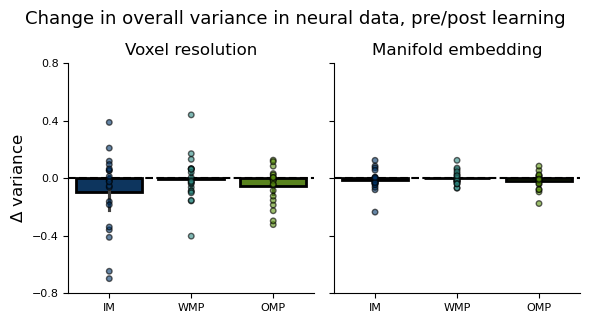

In [13]:
fig,ax=plt.subplots(1,2,figsize=(6,3), sharex=True, sharey=True)
colors_main = {'OMP': '#5C940D', 'WMP': '#2E8A82', 'IM': '#00356b'}
colors=[colors_main[c] for c in ['IM','WMP','OMP']]

g=sns.barplot(ax=ax[0], data=df[df['data_type']=='voxel_data'], x='session_type', y='delta_total_variance', 
              edgecolor='k',palette=colors, alpha=1)
g=sns.stripplot(ax=ax[0], data=df[df['data_type']=='voxel_data'], x='session_type', y='delta_total_variance', 
              edgecolor='k',palette=colors, alpha=0.6,linewidth=1,s=4,jitter=False)
ax[0].axhline(0, ls='--', c='k') 
g.set(xlabel='', ylabel=r'$\Delta$ variance', title='Voxel resolution',ylim=[-0.8,0.8],yticks=np.arange(-0.8,0.9,0.4))

g=sns.barplot(ax=ax[1], data=df[df['data_type']=='manifold_projection'], x='session_type', y='delta_total_variance', 
              edgecolor='k',palette=colors, alpha=1)
g=sns.stripplot(ax=ax[1], data=df[df['data_type']=='manifold_projection'], x='session_type', y='delta_total_variance', 
              edgecolor='k',palette=colors, alpha=0.6,linewidth=1,s=4,jitter=False)

ax[1].axhline(0, ls='--', c='k') 
g.set(xlabel='', ylabel="", title='Manifold embedding')
 




sns.despine()
fig.tight_layout()

plt.suptitle('Change in overall variance in neural data, pre/post learning', fontsize=13, y=1.06)
plt.savefig('revision_plots/neural_variance_change.pdf', transparent=True, format='pdf')

# low vs high readouts onto components

In [11]:
results_df = pd.DataFrame(columns=['subject_id','session_id','session_type','run','total_variance_readout_component',
                                   'average_trialwise_variance_readout_component','variance_decoded_angles'])

for sub in SUB_IDS:
    if sub in ['avatarRT_sub_09','avatarRT_sub_20']:
        continue
    subject_info = cumulative_info[cumulative_info['subject_ID'] == sub ]
    # for ses_str,comp_str in zip(['im_session','wmp_session','omp_session'],['im_component','wmp_component','omp_component']):
    
    # loads the 0th index component (the IM)
    im_session = int(subject_info['im_session'].item())
    im_component, im_idx = 0, 0

    # loads the WMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    wmp_session = int(subject_info['wmp_session'].item())
    wmp_component=int(subject_info['wmp_component'].item())
    wmp_idx = wmp_component
    if wmp_component != 1: wmp_idx = wmp_component - 1
    else: wmp_idx = 1

    # loads the OMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    omp_session = int(subject_info['omp_session'].item())
    omp_component=int(subject_info['omp_component'].item())
    omp_idx = omp_component - 1 
    
    for ses_type, ses_num, comp_idx in zip(['IM','WMP','OMP'],[im_session,wmp_session,omp_session],[im_idx,wmp_idx,omp_idx]):
        if ses_type=="IM":
            first_run=1
        else:
            first_run=2
        final_run=4
        
        XTargetTrial_first = helper.load_component_data(sub , f"ses_0{ses_num}", first_run, component_number=0, by_trial=True, shift_by=2)
        XTargetTrial_final = helper.load_component_data(sub , f"ses_0{ses_num}", final_run, component_number=0, by_trial=True, shift_by=2)
        
        Xtotal_first = np.concatenate([value[:, comp_idx] for key,value in XTargetTrial_first.items()])
        Xtotal_final = np.concatenate([value[:, comp_idx] for key,value in XTargetTrial_final.items()])
        
        Trialwise_Var_first = [helper.compute_total_variance(value[:,comp_idx]) for _,value in XTargetTrial_first.items()]
        Trialwise_Var_final = [helper.compute_total_variance(value[:,comp_idx]) for _,value in XTargetTrial_final.items()]
        
        decoded_angles_first = helper.get_realtime_outdata(sub , f"ses_0{ses_num}", first_run, data_type='decoded_angles')
        decoded_angles_final = helper.get_realtime_outdata(sub , f"ses_0{ses_num}", final_run, data_type='decoded_angles')
        
        results_df.loc[len(results_df)] = {'subject_id':sub,
                                           'session_id':f'ses_0{ses_num}',
                                           'session_type':ses_type,
                                           'run':'first_run',
                                           'total_variance_readout_component':np.var(Xtotal_first),
                                   'average_trialwise_variance_readout_component':np.mean(Trialwise_Var_first),
                                           'variance_decoded_angles':np.nanvar(decoded_angles_first)}
        
        results_df.loc[len(results_df)] = {'subject_id':sub,
                                           'session_id':f'ses_0{ses_num}',
                                           'session_type':ses_type,
                                           'run':'final_run',
                                           'total_variance_readout_component':np.var(Xtotal_final),
                                   'average_trialwise_variance_readout_component':np.mean(Trialwise_Var_final),
                                           'variance_decoded_angles':np.nanvar(decoded_angles_final)}
        
        results_df.loc[len(results_df)] = {'subject_id':sub,
                                           'session_id':f'ses_0{ses_num}',
                                           'session_type':ses_type,
                                           'run':'final-first',
                                           'total_variance_readout_component':np.var(Xtotal_final)-np.var(Xtotal_first),
                                   'average_trialwise_variance_readout_component':np.mean(Trialwise_Var_final)-np.mean(Trialwise_Var_first),
                                           'variance_decoded_angles':np.nanvar(decoded_angles_final)-np.nanvar(decoded_angles_first)}
        
        

appending to reg df
appending to reg df
After getting trial data, found 25 trials, data shape: 25, Xshape: (299, 20)
appending to reg df
After getting trial data, found 18 trials, data shape: 18, Xshape: (308, 20)
After getting trial data, found 21 trials, data shape: 21, Xshape: (296, 20)
appending to reg df
After getting trial data, found 16 trials, data shape: 16, Xshape: (327, 20)
appending to reg df
appending to reg df
After getting trial data, found 9 trials, data shape: 9, Xshape: (189, 20)
appending to reg df
appending to reg df
After getting trial data, found 11 trials, data shape: 11, Xshape: (285, 20)
appending to reg df
appending to reg df
After getting trial data, found 12 trials, data shape: 12, Xshape: (153, 20)
appending to reg df
appending to reg df
After getting trial data, found 16 trials, data shape: 16, Xshape: (303, 20)
appending to reg df
After getting trial data, found 20 trials, data shape: 20, Xshape: (296, 20)
appending to reg df
After getting trial data, fou

In [12]:
diff_df = results_df[results_df['run']=='final-first']
zeros = np.zeros(18)
a = diff_df[(diff_df['session_type']=='WMP')]['total_variance_readout_component'].values
_,p_wmp,_=helper.permutation_test(np.array((a, zeros)), 10000)

a = diff_df[(diff_df['session_type']=='IM')]['total_variance_readout_component'].values
_,p_im,_=helper.permutation_test(np.array((a,zeros)), 10000)

a = diff_df[(diff_df['session_type']=='OMP')]['total_variance_readout_component'].values
_,p_omp,_=helper.permutation_test(np.array((a,zeros)), 10000)


IM 0.063, WM 0.0755, OM 0.9491
greater
IMvWM: 0.1808, IMvOM: 0.001, WMvOM: 0.01


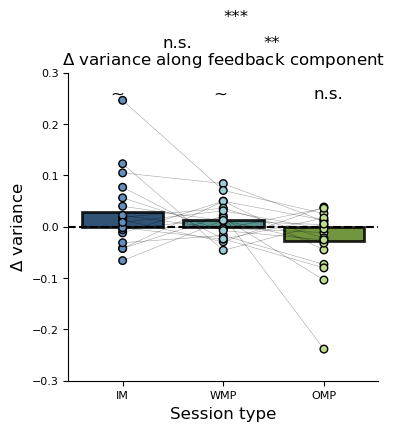

In [18]:
fig, ax = make_barplot_points(diff_df, 'total_variance_readout_component', 'session_type', exclude_subs=[9,12,20], 
                       ylim=[-0.5,0.4], lines=True, outfn=None, 
                              title=r'$\Delta$ variance along feedback component', 
                              plus_bot=0.1, plus_top=0.15, n_iter=1000,  
                       )
ax.set_ylim(-0.3, 0.3)
ax.set_xlabel('Session type')
ax.set_ylabel(r'$\Delta$ variance')
# ax.text(0-0.05, 0.28, s=determine_symbol(p_im), size=16)
# ax.text(1-0.05, 0.28, s=determine_symbol(p_wmp), size=16)
# ax.text(2-0.05, 0.28, s=determine_symbol(p_omp), size=12)
ax.set_title(r'$\Delta$ variance along feedback component')
plt.savefig('revision_plots/delta_variance_feedback_components.pdf', transparent=True, format='pdf')

In [4]:
cumulative_info = helper.load_info_file()


In [342]:
cumulative_info = helper.load_info_file()

results_df = pd.DataFrame(columns=['subject_id','session_id','session_type','run','total_variance_readout_component',
                                   'average_trialwise_variance_readout_component','variance_decoded_angles']

for sub in SUB_IDS:
    if sub in ['avatarRT_sub_09','avatarRT_sub_20']:
        continue
    
    fig,ax=plt.subplots(3, 2, figsize=(8, 12),sharey=True)

    subject_info = cumulative_info[cumulative_info['subject_ID'] == sub ]
        
    # loads the 0th index component (the IM)
    im_session = int(subject_info['im_session'].item())
    im_component, im_idx = 0, 0

    # loads the WMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    wmp_session = int(subject_info['wmp_session'].item())
    wmp_component=int(subject_info['wmp_component'].item())
    wmp_idx = wmp_component
    if wmp_component != 1: wmp_idx = wmp_component - 1
    else: wmp_idx = 1

    # loads the OMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    omp_session = int(subject_info['omp_session'].item())
    omp_component=int(subject_info['omp_component'].item())
    omp_idx = omp_component - 1 
    
    
    # get data for each session
    DATA_BY_SES = {}
    DEC_ANGLE_BY_SES = {}
    
    # IM
    IM_XTargetTrial_first = helper.load_component_data(sub , f"ses_0{im_session}", 1, component_number=0, by_trial=True, shift_by=2)
    IM_XTargetTrial_first= np.concatenate([value[:,im_idx] for key,value in IM_XTargetTrial_first.items()])
    
    IM_XTargetTrial_final = helper.load_component_data(sub , f"ses_0{im_session}", 4, component_number=0, by_trial=True, shift_by=2)
    IM_XTargetTrial_final = np.concatenate([value[:,im_idx] for key,value in IM_XTargetTrial_final.items()])
    
    IM_decoded_angles_first = helper.get_realtime_outdata(sub , f"ses_0{im_session}", 1, data_type='decoded_angles')
    IM_decoded_angles_final = helper.get_realtime_outdata(sub , f"ses_0{im_session}", 4, data_type='decoded_angles')

    sns.histplot(np.abs(IM_decoded_angles_first),kde=True,label='Pre-',ax=ax[0][0])
    g=sns.histplot(np.abs(IM_decoded_angles_final),kde=True,label='Post-',ax=ax[0][0])
    g.set(title='IM ses: Decoded angles')
    g.legend()

    sns.histplot(np.abs(IM_XTargetTrial_first),kde=True,label='Pre-',ax=ax[0][1])
    g=sns.histplot(np.abs(IM_XTargetTrial_final),kde=True,label='Post-',ax=ax[0][1])
    g.set(title='IM ses: Feedback component projections')
    
    # WMP
    WM_XTargetTrial_first = helper.load_component_data(sub , f"ses_0{wmp_session}", 1, component_number=0, by_trial=True, shift_by=2)
    WM_XTargetTrial_first= np.concatenate([value[:,wmp_idx] for key,value in WM_XTargetTrial_first.items()])
    
    WM_XTargetTrial_final = helper.load_component_data(sub , f"ses_0{wmp_session}", 4, component_number=0, by_trial=True, shift_by=2)
    WM_XTargetTrial_final = np.concatenate([value[:,wmp_idx] for key,value in WM_XTargetTrial_final.items()])
    
    WM_decoded_angles_first = helper.get_realtime_outdata(sub , f"ses_0{wmp_session}", 1, data_type='decoded_angles')
    WM_decoded_angles_final = helper.get_realtime_outdata(sub , f"ses_0{wmp_session}", 4, data_type='decoded_angles')

    sns.histplot(np.abs(WM_decoded_angles_first),kde=True,label='Pre-',ax=ax[1][0])
    g=sns.histplot(np.abs(WM_decoded_angles_final),kde=True,label='Post-',ax=ax[1][0])
    g.set(title='WM ses: Decoded angles')
    g.legend()

    sns.histplot(np.abs(WM_XTargetTrial_first),kde=True,label='Pre-',ax=ax[1][1])
    g=sns.histplot(np.abs(WM_XTargetTrial_final),kde=True,label='Post-',ax=ax[1][1])
    g.set(title='WM ses: Feedback component projections')
    
    # OMP
    OM_XTargetTrial_first = helper.load_component_data(sub , f"ses_0{omp_session}", 2, component_number=0, by_trial=True, shift_by=2)
    OM_XTargetTrial_first= np.concatenate([value[:,omp_idx] for key,value in OM_XTargetTrial_first.items()])
    
    OM_XTargetTrial_final = helper.load_component_data(sub , f"ses_0{omp_session}", 4, component_number=0, by_trial=True, shift_by=2)
    OM_XTargetTrial_final = np.concatenate([value[:,omp_idx] for key,value in OM_XTargetTrial_final.items()])
    
    OM_decoded_angles_first = helper.get_realtime_outdata(sub , f"ses_0{omp_session}", 2, data_type='decoded_angles')
    OM_decoded_angles_final = helper.get_realtime_outdata(sub , f"ses_0{omp_session}", 4, data_type='decoded_angles')

    sns.histplot(np.abs(OM_decoded_angles_first),kde=True,label='Pre-',ax=ax[2][0])
    g=sns.histplot(np.abs(OM_decoded_angles_final),kde=True,label='Post-',ax=ax[2][0])
    g.set(title='OM ses: Decoded angles')
    g.legend()

    sns.histplot(np.abs(OM_XTargetTrial_first),kde=True,label='Pre-',ax=ax[2][1])
    g=sns.histplot(np.abs(OM_XTargetTrial_final),kde=True,label='Post-',ax=ax[2][1])
    g.set(title='OM ses: Feedback component projections')
    sns.despine()
    plt.savefig(f'revision_plots/{sub}_projection_variance_plots.pdf', format='pdf', transparent=True)
    plt.close()



appending to reg df
appending to reg df
After getting trial data, found 25 trials, data shape: 25, Xshape: (299, 20)
appending to reg df
After getting trial data, found 18 trials, data shape: 18, Xshape: (308, 20)
After getting trial data, found 25 trials, data shape: 25, Xshape: (297, 20)
appending to reg df
After getting trial data, found 16 trials, data shape: 16, Xshape: (327, 20)
appending to reg df
appending to reg df
After getting trial data, found 9 trials, data shape: 9, Xshape: (189, 20)
appending to reg df
appending to reg df
After getting trial data, found 11 trials, data shape: 11, Xshape: (285, 20)
appending to reg df
appending to reg df
After getting trial data, found 12 trials, data shape: 12, Xshape: (153, 20)
appending to reg df
appending to reg df
After getting trial data, found 16 trials, data shape: 16, Xshape: (303, 20)
appending to reg df
appending to reg df
After getting trial data, found 22 trials, data shape: 22, Xshape: (295, 20)
appending to reg df
After get

In [370]:
def get_ev_trialseries(subject_id, session_id, run, component_idx):
    x=helper.load_component_data(subject_id , f"ses_0{im_session}", run, component_number=0, by_trial=True, shift_by=2)
    evrs=[helper.run_EVR(value)[component_idx] for _, value in x.items()]
    var=[helper.compute_total_variance(value[:,component_idx]) for _,value in x.items()]
    return var

# decoding results

## Joystick results

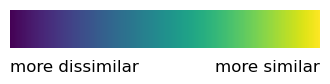

In [258]:
fig, ax = plt.subplots(figsize=(4, 1))
fig.subplots_adjust(bottom=0.5)

# Create a colormap normalization from 0 to 1
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cbar = mpl.colorbar.ColorbarBase(
    ax, cmap=plt.cm.viridis, norm=norm, orientation='horizontal'
)

# Remove default ticks
cbar.set_ticks([])

# Add custom labels
ax.text(0, -0.5, 'more dissimilar', ha='left', va='center', fontsize=12)
ax.text(1, -0.5, 'more similar', ha='right', va='center', fontsize=12, transform=ax.transAxes)

# Remove axis
ax.set_axis_off()
plt.savefig('revision_plots/viridis_cb.pdf', format='pdf', transparent=True)

In [36]:
fig1 = pd.read_csv('results/final_results/joystick_decoding_results_final.csv' )
fig1_full=fig1[(fig1['embedding_type'].isin(['tphate','voxel','pca'])) & (fig1['embedding_dim']==20) & (~fig1['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20']))]


In [39]:
fig1_full.to_csv('results/results_public/joystick_decoding_results.csv')

/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/gpfs/milgram/pi/turk-browne/users/elb77/BCI/rt-cloud/projects/avatarRT/offline_analyses/final_analysis_scripts/analysis_helpers.py:107: RuntimeWarning: Mean of empty slice.
  null_distribution[i] = (weights*observed_difference).mean()


0.00019998000199980003


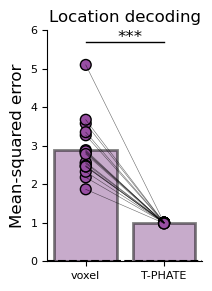

In [57]:

fig,ax=plt.subplots(1,1, figsize=(2,3))
pal = [sns.color_palette('Set1',6)[3] for i in [1,-1]]
subset = fig1_full[fig1_full['metric']=='himalaya']
g=sns.barplot(x='embedding_type', y='score', data=subset, palette=pal,ax=ax, alpha=0.5, 
              edgecolor='k',linewidth=2,errorbar=None, order=['voxel','tphate'])
ax.axhline(0, ls='--', c='k') 
points0,points1=[],[]
#g=sns.stripplot(x='embedding', y=ynames[i], data=res, palette='inferno', ax=ax, alpha=1, linewidth=1)
_,pv,_=helper.permutation_test(np.array([points0,points1]),n_iterations=10000,alternative='two-sided')
print(pv)
for sub in fig1_full.subject_id.unique():
    p0 = subset[(subset['subject_id']==sub)&(subset['embedding_type']=='voxel')]['score'].item()
    p1 = subset[(subset['subject_id']==sub)&(subset['embedding_type']=='tphate')]['score'].item()
    points0.append(p0)
    points1.append(p1)
    ax.scatter([0,1],[p0,p1],linewidth=1,s=60,edgecolors='k', c=[pal[0], pal[1]])
    ax.plot([0,1],[p0,p1],color='k',alpha=0.6, linewidth=0.4)

yloc = np.ceil(np.max((points0,points1)))-0.3
plt.axhline(y=yloc, xmin=0+0.25, xmax=1-0.25, color='k', lw=1)
plt.text(x=0.4, y=yloc, s=determine_symbol(pv), size=12)

g.set(title="Location decoding", xticklabels=['voxel','T-PHATE'], ylabel="Mean-squared error", xlabel='', ylim=[0,6])
sns.despine()
plt.savefig('revision_plots/figure1C_decoding.pdf', format='pdf', transparent=True)

In [54]:
helper.permutation_test

<function analysis_helpers.permutation_test(data, n_iterations, alternative='greater')>

/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/gpfs/milgram/pi/turk-browne/users/elb77/BCI/rt-cloud/projects/avatarRT/offline_analyses/final_analysis_scripts/analysis_helpers.py:107: RuntimeWarning: Mean of empty slice.
  null_distribution[i] = (weights*observed_difference).mean()


0.00019998000199980003


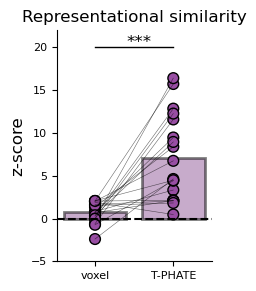

In [56]:
fig,ax=plt.subplots(1,1, figsize=(2,3))
pal = [sns.color_palette('Set1',6)[3] for i in [1,-1]]
fig1_full=fig1[(fig1['embedding_type'].isin(['tphate','voxel'])) & (fig1['embedding_dim']==20) & (~fig1['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20']))]

subset = fig1_full[fig1_full['metric']=='z']
g=sns.barplot(x='embedding_type', y='score', data=subset, palette=pal,ax=ax, alpha=0.5, 
              edgecolor='k',linewidth=2,errorbar=None, order=['voxel','tphate'])
ax.axhline(0, ls='--', c='k') 
points0,points1=[],[]
_,pv,_=helper.permutation_test(np.array([points0,points1]),n_iterations=10000,alternative='two-sided')
print(pv)
for sub in subset.subject_id.unique():
    p0 = subset[(subset['subject_id']==sub)&(subset['embedding_type']=='voxel')]['score'].item()
    p1 = subset[(subset['subject_id']==sub)&(subset['embedding_type']=='tphate')]['score'].item()
    points0.append(p0)
    points1.append(p1)
    ax.scatter([0,1],[p0,p1],linewidth=1,s=60,edgecolors='k', c=[pal[0], pal[1]])
    ax.plot([0,1],[p0,p1],color='k',alpha=0.6, linewidth=0.4)

yloc = 20#np.ceil(np.max((points0,points1)))+1.5
plt.axhline(y=yloc, xmin=0+0.25, xmax=1-0.25, color='k', lw=1)
plt.text(x=0.4, y=yloc, s=determine_symbol(pv), size=12)

g.set(title="Representational similarity", xticklabels=['voxel','T-PHATE'], ylabel="z-score", xlabel='', ylim=[-5,22])
sns.despine()
plt.savefig('revision_plots/figure1D_RSA.pdf', format='pdf', transparent=True)

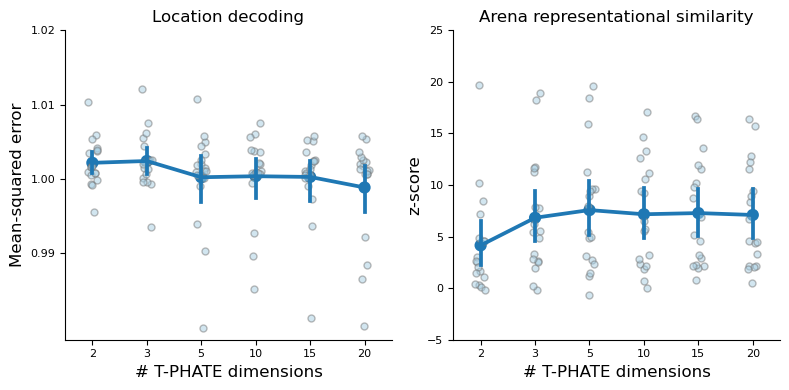

In [58]:
fig,ax=plt.subplots(1,2,figsize=(8,4))

pal = sns.color_palette('Paired')[:4]
temp = fig1[fig1['embedding_type']=='tphate'].groupby(['metric', 'embedding_dim', 'subject_id']).mean().reset_index()

sns.pointplot(data=temp[temp['metric']=="himalaya"],  x='embedding_dim', y='score', ax=ax[0], color=pal[1])
g=sns.stripplot(data=temp[temp['metric']=="himalaya"],  x='embedding_dim', y='score',ax=ax[0], alpha=0.5, linewidth=1, 
                ec='k',color=pal[0], zorder=1)
g.set(xlabel='# T-PHATE dimensions', ylabel='Mean-squared error', 
      title='Location decoding', yticks=[0.99, 1.00, 1.01, 1.02])


sns.pointplot(data=temp[temp['metric']=="z"],  x='embedding_dim', y='score',ax=ax[1], color=pal[1])
g=sns.stripplot(data=temp[temp['metric']=="z"],  x='embedding_dim', y='score',alpha=0.5, linewidth=1, 
                ec='k',color=pal[0], zorder=1,ax=ax[1])
g.set(xlabel='# T-PHATE dimensions', ylabel='z-score', 
      ylim=[-5,25], title='Arena representational similarity')

sns.despine()
fig.tight_layout()
plt.savefig('revision_plots/decoding_mse_dimensions.pdf', format='pdf', transparent=True)

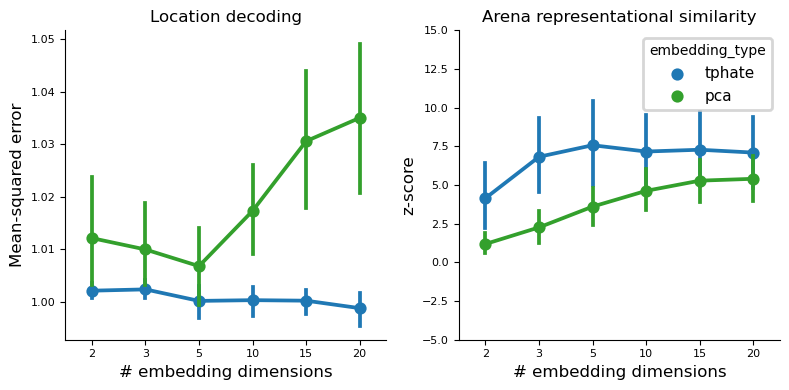

In [64]:
fig,ax=plt.subplots(1,2,figsize=(8,4))

temp = fig1[fig1['embedding_type'].isin(['tphate','pca'])].groupby(['embedding_type','metric', 'embedding_dim', 'subject_id']).mean().reset_index()

g=sns.pointplot(data=temp[temp['metric']=="himalaya"],  x='embedding_dim', 
              y='score', hue='embedding_type', ax=ax[0], hue_order=['tphate','pca'], palette=[pal[1], pal[3]] )

# g=sns.stripplot(data=temp[temp['metric']=="himalaya"],  x='embedding_dim', hue='embedding_type',dodge=True,
#                y='score',ax=ax[0], alpha=0.5, linewidth=1, 
#                ec='k', palette=[pal[0], pal[2]], zorder=1, hue_order=['tphate','pca'])

g.set(xlabel='# embedding dimensions', ylabel='Mean-squared error', 
      title='Location decoding' )


g=sns.pointplot(data=temp[temp['metric']=="z"],  x='embedding_dim', y='score',ax=ax[1], 
                hue='embedding_type', palette=[pal[1], pal[3]], hue_order=['tphate','pca'])
# g=sns.stripplot(data=temp[temp['metric']=="z"],  x='embedding_dim',dodge=True, y='score',hue='embedding_type',alpha=0.5, linewidth=1, 
#                ec='k',palette=[pal[0], pal[2]], zorder=1,ax=ax[1], hue_order=['tphate','pca'])
g.set(xlabel='# embedding dimensions', ylabel='z-score', 
      ylim=[-5,15], title='Arena representational similarity')
if ax[0].legend_ is not None: # Check if legend exists
    ax[0].legend_.remove()

sns.despine()
fig.tight_layout()
plt.savefig('revision_plots/decoding_mse_pca_dimensions.pdf', format='pdf', transparent=True)

## new consolidation after learning

In [3]:
df_evr = pd.read_csv('results/final_results/runwise_component_EVR_neural_analysis_run_change_control.csv', index_col=0)
# exclude subs
df_evr = df_evr[~df_evr['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20'])]
dfa = df_evr[df_evr['congruent']==True]

In [4]:
df_dec = pd.read_csv('results/intermediate_results/decoding_results_jul30_cross_session_run_cross_validation.csv', index_col=0)
df_cong = df_dec[df_dec['congruent']==True]

In [5]:
df_dec = pd.read_csv('results/intermediate_results/decoding_results_jul30_cross_session_run_cross_validation.csv', index_col=0)
df_dec = df_dec[~df_dec['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20'])]
df_switch = df_dec[df_dec['train_session_type']=='IM']
idx1 = df_switch[df_switch['test_session_type']=='WMP'].index
idx2 = df_switch[df_switch['test_session_type']=='OMP'].index
df_switch.loc[idx1,'test_session_type']='OMP'
df_switch.loc[idx2,'test_session_type']='WMP'

df_switch = df_switch[~df_switch['subject_id'].isin(['avatarRT_sub_09','avatarRT_sub_20'])]

# subtraction analysis

df_difference = pd.DataFrame(columns=['train_session_type','test_session_type','subject_id','delta_mse','delta_evr'])

for sub in df_switch.subject_id.unique():
    for test_type in ['IM','WMP','OMP']:
        temp=df_switch[(df_switch['test_session_type']==test_type)&(df_switch['subject_id']==sub)]
        val=dfa[(dfa['session_type']==test_type) & (dfa['subject_id']==sub)]['delta_evr_since_perturb'].item()
        first_run = temp[temp['test_run']==1]['mse'].item()
        final_run = temp[temp['test_run']==4]['mse'].item()
        df_difference.loc[len(df_difference)] = {'train_session_type':'IM',
                                                 'test_session_type':test_type,
                                                 'subject_id':sub,
                                                 'delta_mse':final_run - first_run,
                                                'delta_evr':val}
        
        
    

In [56]:
make_barplot_points(df_cong_avg, "mse", "test_session_type", exclude_subs=[9,20], ylim=[0, 1.5], 
                    outfn="revision_plots/decoders_within_session.pdf", title='Decoders evaluated within session',plus_bot=0.2, plus_top=0.35, n_iter=10000, 
                    sample_alternative='greater',
                    pairwise_alternative='two-sided',ylabel='MSE', xlabel='Session type')

IM 0.0, WM 0.0, OM 0.0
two-sided
IMvWM: 0.6761, IMvOM: 0.7245, WMvOM: 0.9721
avatarRT_sub_12


In [17]:
a[0]

array([ 0.00368384, -0.21964989,  0.00673162, -0.02538491,  0.10091477,
       -0.07445711,  0.03011393,  0.10042462,  0.07934582,  0.14652833,
       -0.04449114,  0.1151105 , -0.02488537, -0.07077165,  0.05698323,
        0.04364909,  0.05117709, -0.14491225])

/gpfs/milgram/project/casey/elb77/conda_envs/rtcloud_av1/lib/python3.7/site-packages/ipykernel_launcher.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  


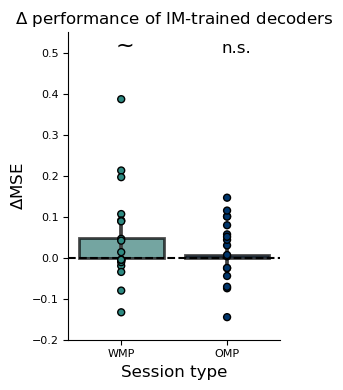

In [8]:
fig,ax=plt.subplots(1,1,figsize=(3,4))
colors=[a for _, a in colors_main.items()]

a = np.array([df_difference[df_difference['test_session_type']=='OMP']['delta_mse'].values, 
              np.zeros(18)])
b = np.array([df_difference[df_difference['test_session_type']=='WMP']['delta_mse'].values, 
              np.zeros(18)])
_,p_omp,_=helper.permutation_test(a, 10000)
_,p_wmp,_=helper.permutation_test(b, 10000)

sns.barplot(data=df_difference, x='test_session_type',order=['WMP','OMP'], y='delta_mse',ax=ax , 
            palette=colors[1:],edgecolor='k',linewidth=2,alpha=0.7)
g=sns.stripplot(data=df_difference, x='test_session_type',order=['WMP','OMP'] , y='delta_mse',ax=ax, 
              palette=colors[1:],edgecolor='k',linewidth=1,jitter=False)
plt.text(x=1-0.05, y=0.5, s=determine_symbol(p_omp), size=12) 
plt.text(x=0-0.05, y=0.5, s=determine_symbol(p_wmp), size=16) 
g.set(title=r'$\Delta$ performance of IM-trained decoders',ylabel=r'$\Delta$MSE',
      xlabel='Session type',ylim=[-0.2, 0.55])
g.axhline(0, color='k', ls='--')
sns.despine()
fig.tight_layout()
# plt.savefig('revision_plots/delta_decoding_performance.pdf', format='pdf', transparent=True)


In [61]:
!mv revision_gromov_wasserstein.csv results/results_public/

# PROJECTIONS ONTO COMPONENTS 

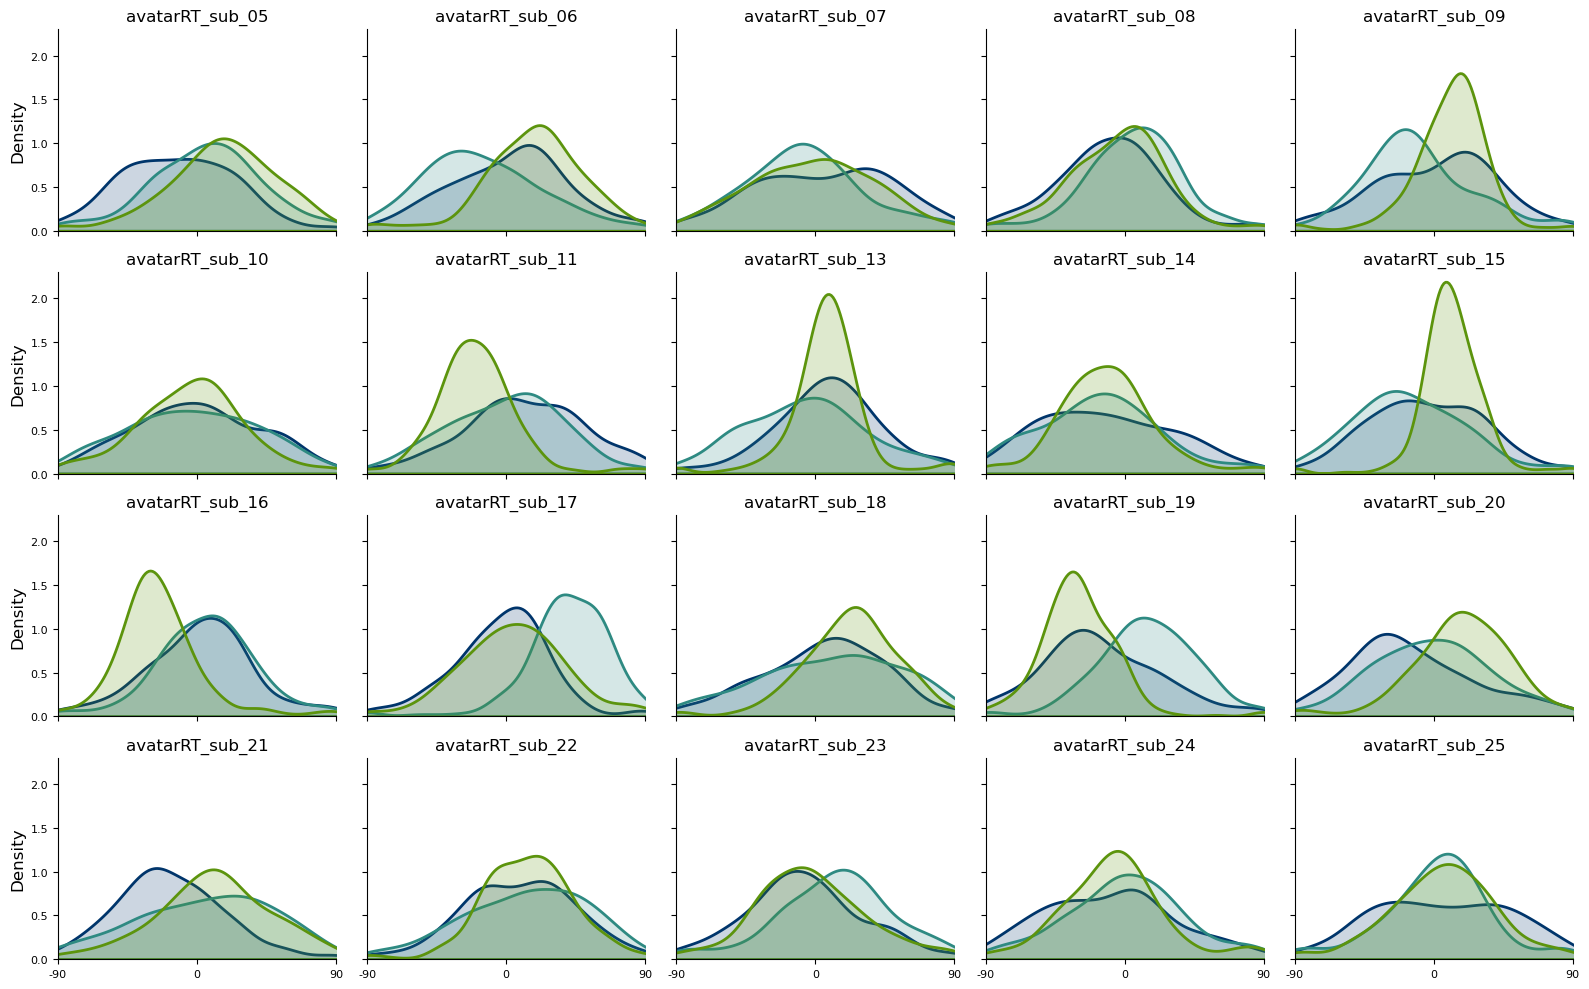

In [129]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()
for i,sub in enumerate(SUB_IDS):
    x=np.load(f'{DATA_PATH}/{sub}/model/projected_test_runs.npy')
    im_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_01.npy')
    wmp_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_02.npy')
    omp_comp = np.load(f'{DATA_PATH}/{sub}/model/manifold_pc_20.npy')
    
    test_range_im = np.load(f'{DATA_PATH}/{sub}/model/test_range_01.npy') 
    test_range_wmp = np.load(f'{DATA_PATH}/{sub}/model/test_range_02.npy') 
    test_range_omp = np.load(f'{DATA_PATH}/{sub}/model/test_range_20.npy') 
    
    slope_im, int_im = np.polyfit(test_range_im, [-1, 1], 1)
    slope_wmp, int_wmp = np.polyfit(test_range_wmp, [-1, 1], 1)
    slope_omp, int_omp = np.polyfit(test_range_omp, [-1, 1], 1)

    
    im_proj = helper.map_projection(x, im_comp)
    wmp_proj = helper.map_projection(x, wmp_comp)
    omp_proj = helper.map_projection(x, omp_comp)
    
    MAP_ANGLE_IM = lambda x : slope_im * x + int_im
    MAP_ANGLE_WMP = lambda x : slope_wmp * x + int_wmp
    MAP_ANGLE_OMP = lambda x : slope_omp * x + int_omp
    
    im_mapped = np.clip(MAP_ANGLE_IM(im_proj), -1, 1)
    wmp_mapped = np.clip(MAP_ANGLE_WMP(wmp_proj), -1, 1)
    omp_mapped = np.clip(MAP_ANGLE_OMP(omp_proj), -1, 1)
    
    sns.kdeplot(im_mapped, label='C_IM',alpha=0.2, fill=True, color=colors_main['IM'],ax=axes[i])
    sns.kdeplot(wmp_mapped, label='C_WM',alpha=0.2, fill=True, color=colors_main['WMP'],ax=axes[i])
    sns.kdeplot(omp_mapped, label='C_OM',alpha=0.2, fill=True, color=colors_main['OMP'],ax=axes[i])
    axes[i].set_title(f'{sub}')
    axes[i].set_xlim([-1, 1])
    axes[i].set_xticks([-1, 0, 1])
    axes[i].set_xticklabels([-90, 0, 90])
    sns.despine()
fig.tight_layout()
plt.savefig('revision_plots/projections.pdf', format='pdf', transparent=True)

# Resampling random effects

In [57]:
resampling_distributions = {'IM':[],'WMP':[],'OMP':[]}
true_stats = {'IM':[],'WMP':[],'OMP':[]}
SUBJECTS = [S for S in SUB_IDS if S not in ['avatarRT_sub_09','avatarRT_sub_20']]
for subject_id in SUBJECTS:
    if subject_id in ['avatarRT_sub_09','avatarRT_sub_20']:
        continue
    subject_info = cumulative_info[cumulative_info['subject_ID'] == subject_id ]

    # loads the 0th index component (the IM)
    im_session = int(subject_info['im_session'].item())
    im_component, im_idx = 0, 0

    # loads the WMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    wmp_session = int(subject_info['wmp_session'].item())
    wmp_component=int(subject_info['wmp_component'].item())
    wmp_idx = wmp_component
    if wmp_component != 1: wmp_idx = wmp_component - 1
    else: wmp_idx = 1

    # loads the OMP; adjusts for 0 indexing (but that 0 is the IM, so 1=1)
    omp_session = int(subject_info['omp_session'].item())
    omp_component=int(subject_info['omp_component'].item())
    omp_idx = omp_component - 1 

    session_name_mapping = {
        'IM': {'session_number':im_session,
               'component_index': im_idx,  
              'runs':[1,4]
              }, 
    'WMP':{'session_number': wmp_session, 
           'component_index': wmp_idx,  'runs':[2,4]}, 

    'OMP':{'session_number':omp_session, 
           'component_index':omp_idx,  'runs':[2,4]}}
    
    for ses_name, ses_info in session_name_mapping.items():
        ses_id = ses_info['session_number']
        ses_id=f'ses_0{ses_id}'
        nfb_component_idx = ses_info['component_index']
        first_run, last_run = SESSION_TYPES_RUNS[ses_name][0], SESSION_TYPES_RUNS[ses_name][-1]
        first_run_X = helper.load_component_data(subject_id , ses_id, first_run, component_number=None, 
                                                 by_trial=False, shift_by=2)
        final_run_X = helper.load_component_data(subject_id, ses_id, last_run, component_number=None,
                                                 by_trial=False, shift_by=2) 
        evr_mat = helper.run_EVR(first_run_X)
        evr_mat2 = helper.run_EVR(final_run_X)
        diff_mat = evr_mat2 - evr_mat
        true_stats[ses_name].append(diff_mat[ses_info['component_index']])
        resampling_distributions[ses_name].append(np.random.choice(diff_mat, 10000)) 

results = pd.DataFrame(columns=['subject_id','session_type','zscored_difference', 'true_difference', 'null_difference'])
for ses, distribs in resampling_distributions.items():
    stats = true_stats[ses]
    for i in range(len(stats)):
        ztrue = (stats[i] - np.mean(distribs[i])) / np.std(distribs[i])
        # get the z-score of 0
        z0 = (0 - np.mean(distribs[i]))/np.std(distribs[i])
        
        results.loc[len(results)] = {'subject_id': SUBJECTS[i], 'session_type':ses, 'zscored_difference':ztrue,
                                     'true_difference': stats[i], 'null_difference':z0}                

In [58]:
np.mean(distribs[i]) / np.std(distribs[i]), stats[i]

(-0.006800555926615169, -0.014898123064823618)

In [59]:
ttest_1samp(resampling_distributions['IM'], popmean=0, axis=1, alternative='greater')

Ttest_1sampResult(statistic=array([-0.01292514,  0.20452933, -0.53460688, -0.23795143,  0.55374021,
       -0.32653138, -1.05688652, -0.09877578,  0.84823562, -0.06087692,
       -0.91126867, -1.19679883,  1.12306806,  1.43180449,  1.83137809,
        0.3681862 , -0.61634366, -0.20743773]), pvalue=array([0.50515611, 0.41897202, 0.70353319, 0.59403818, 0.28988452,
       0.62798541, 0.85470554, 0.53934086, 0.19816353, 0.52427078,
       0.8189121 , 0.88429333, 0.13071778, 0.07611552, 0.03353693,
       0.3563711 , 0.73115912, 0.58216388]))

In [60]:
results.to_csv('results/results_public/random_resampling_components.csv')

In [24]:
make_barplot_points(results, "zscored_difference", "session_type", exclude_subs=[9,20], ylim=[-2.5, 3], 
                    outfn="revision_plots/zscored_differences.pdf", title='',plus_bot=0.8, plus_top=1.3, n_iter=10000, sample_alternative='greater',
                    pairwise_alternative='greater',ylabel='Z-Scores', xlabel='Session type')

IM 0.0016, WM 0.0325, OM 0.7683
greater
IMvWM: 0.2818, IMvOM: 0.0045, WMvOM: 0.0312
avatarRT_sub_12


In [87]:
make_barplot_points(results, "null_difference", "session_type", exclude_subs=[9,20], ylim=[-0.01, 0.01],
                    outfn="revision_plots/mean_null1.pdf", title='',  n_iter=10000, sample_alternative='greater',
                    pairwise_alternative='greater',ylabel='z(0) of null', xlabel='Session type')

IM 0.3407, WM 0.0556, OM 0.6489
greater
IMvWM: 0.8176, IMvOM: 0.2925, WMvOM: 0.0537
avatarRT_sub_12


In [98]:
model = smf.ols('delta_BC ~ delta_EVR * C(session_type)', data= main_results )
indiv_diff_results = model.fit()
print(indiv_diff_results.summary())
# ============================================================================
# ANOVA TABLE AND F-TESTS
# ============================================================================
print("\n" + "="*60)
print("ANOVA TABLE AND F-TESTS")
print("="*60)

# Perform ANOVA on the OLS model
anova_table = anova_lm(indiv_diff_results, typ=2)  # Type II ANOVA
print("\nType II ANOVA Results:")
print(anova_table.round(6))

# Extract F-statistics and p-values for reporting
f_session = anova_table.loc['C(session_type)', 'F']
p_session = anova_table.loc['C(session_type)', 'PR(>F)']
df_session_num = anova_table.loc['C(session_type)', 'df']
df_session_den = anova_table.loc['Residual', 'df']

f_evr = anova_table.loc['delta_EVR', 'F']
p_evr = anova_table.loc['delta_EVR', 'PR(>F)']
df_evr_num = anova_table.loc['delta_EVR', 'df']
df_evr_den = anova_table.loc['Residual', 'df']

f_interaction = anova_table.loc['delta_EVR:C(session_type)', 'F']
p_interaction = anova_table.loc['delta_EVR:C(session_type)', 'PR(>F)']
df_interaction_num = anova_table.loc['delta_EVR:C(session_type)', 'df']
df_interaction_den = anova_table.loc['Residual', 'df']

# ============================================================================
# EFFECT SIZES (Partial Eta-Squared)
# ============================================================================
print("\n" + "="*60)
print("EFFECT SIZES (PARTIAL ETA-SQUARED)")
print("="*60)

def partial_eta_squared(anova_table, effect_name):
    """Calculate partial eta-squared from ANOVA table"""
    ss_effect = anova_table.loc[effect_name, 'sum_sq']
    ss_error = anova_table.loc['Residual', 'sum_sq']
    return ss_effect / (ss_effect + ss_error)

eta2_session = partial_eta_squared(anova_table, 'C(session_type)')
eta2_evr = partial_eta_squared(anova_table, 'delta_EVR')
eta2_interaction = partial_eta_squared(anova_table, 'delta_EVR:C(session_type)')

print(f"Partial η² for Session Type: {eta2_session:.3f}")
print(f"Partial η² for Group Order: {eta2_evr:.3f}")
print(f"Partial η² for Interaction: {eta2_interaction:.3f}")

# Model R-squared
r_squared = indiv_diff_results.rsquared
r_squared_adj = indiv_diff_results.rsquared_adj
print(f"\nModel R²: {r_squared:.3f}")
print(f"Adjusted R²: {r_squared_adj:.3f}")


print("\n" + "="*60)
print("SUMMARY")
print("="*60)

# Create summary dictionary
results_summary = {
'Main_Effect_Session': {
    'F': f_session,
    'df_num': df_session_num,
    'df_den': df_session_den,
    'p_value': p_session,
    'eta_squared': eta2_session,
    'significant': p_session < 0.05
},
'Main_Effect_Group': {
    'F': f_group,
    'df_num': df_evr_num,
    'df_den': df_evr_den,
    'p_value': p_evr,
    'eta_squared': eta2_evr,
    'significant': p_evr < 0.05
},
'Interaction': {
    'F': f_interaction,
    'df_num': df_interaction_num,
    'df_den': df_interaction_den,
    'p_value': p_interaction,
    'eta_squared': eta2_interaction,
    'significant': p_interaction < 0.05
},
'Model_Fit': {
    'R_squared': r_squared,
    'R_squared_adj': r_squared_adj
}
}

print("\nFinal Summary:")
print(f"Session Type Effect: F({df_session_num:.0f},{df_session_den:.0f}) = {f_session:.2f}, {format_p_value(p_session)}, η²p = {eta2_session:.3f}")
print(f"Group Order Effect: F({df_evr_num:.0f},{df_evr_den:.0f}) = {f_evr:.2f}, {format_p_value(p_evr)}, η²p = {eta2_evr:.3f}")
print(f"Interaction Effect: F({df_interaction_num:.0f},{df_interaction_den:.0f}) = {f_interaction:.2f}, {format_p_value(p_interaction)}, η²p = {eta2_interaction:.3f}")

                            OLS Regression Results                            
Dep. Variable:               delta_BC   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     24.72
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           3.15e-12
Time:                        13:11:03   Log-Likelihood:                 32.126
No. Observations:                  54   AIC:                            -52.25
Df Residuals:                      48   BIC:                            -40.32
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# Comparison of intrinsic manifold across days

In [4]:
def prep_joystick_data(subject_id):
    temp_fn = f'{SCRATCH_PATH}/joystick_analyses/{subject_id}_20d_TPHATE_embedding.npy'
    if os.path.exists(temp_fn):
        print(f'loading in file')
        tph_dst=np.load(temp_fn)
        return tph_dst
    mask_arr = nib.load(f'{DATA_PATH}/{subject_id}/reference/mask.nii.gz').get_fdata()
    data, trial_labels, x_vals, z_vals, run_labels =  [], [], [], [], []
    for run in range(1,5):
        ds, ti, xi, zi = helper.load_all_joystick_data(subject_id, run, mask_arr, shift_by)
        ds_trial = ds[ti>=0]
        data.append(ds_trial)
    voxel_data = np.concatenate(data,axis=0)
    tph_dst = tphate.TPHATE(verbose=0, n_components=20, t=5).fit_transform(voxel_data)
    np.save(temp_fn, tph_dst)
    return tph_dst

def prep_rt_data(subject_id, session_id):
    temp_fn = f'{SCRATCH_PATH}/joystick_analyses/{subject_id}_{session_id}_RT_20d_TPHATE_embedding.npy'
    if os.path.exists(temp_fn):
        print(f'loading in file {temp_fn}')
        tph_dst=np.load(temp_fn)
        return tph_dst
    data = []
    for run in range(1,5):
        d = helper.get_realtime_data_preprocesssed(subject_id, session_id, run, data_type=None)
        data.append(d)
    voxel_data = np.concatenate(data,axis=0)
    tph_dst = tphate.TPHATE(verbose=0, n_components=20, t=5).fit_transform(voxel_data)
    np.save(temp_fn, tph_dst)
    return tph_dst

In [5]:
# estimate as separate spaces and compute gromov-wasserstein

In [6]:
import ot

In [171]:
# df = pd.DataFrame(columns=['subject_id', 'sesA', 'sesB', 'gw2'])
for subject_id in SUB_IDS[-2:]:
    if subject_id in ['avatarRT_sub_09','avatarRT_sub_20']:
        continue
    subject_info = cumulative_info[cumulative_info['subject_ID'] == subject_id ]
    im_session = int(subject_info['im_session'].item())
    wmp_session = int(subject_info['wmp_session'].item())
    omp_session = int(subject_info['omp_session'].item())
    
    joystick_mani = prep_joystick_data(subject_id)
    im_session_mani = prep_rt_data(subject_id, f'ses_0{im_session}')
    wmp_session_mani = prep_rt_data(subject_id, f'ses_0{wmp_session}')
    omp_session_mani = prep_rt_data(subject_id, f'ses_0{omp_session}')
    
    JM = squareform(pdist(joystick_mani),'euclidean')
    IMM = squareform(pdist(im_session_mani),'euclidean')
    WMM = squareform(pdist(wmp_session_mani),'euclidean')
    OMM = squareform(pdist(omp_session_mani),'euclidean')
    print(f'got manis')
    g0 = ot.gromov.gromov_wasserstein2(JM, IMM)
    g1 = ot.gromov.gromov_wasserstein2(JM, WMM)
    g2 = ot.gromov.gromov_wasserstein2(JM, OMM)
    g3 = ot.gromov.gromov_wasserstein2(WMM, IMM)
    g4 = ot.gromov.gromov_wasserstein2(WMM, OMM)
    
    df.loc[len(df)] = {'subject_id': subject_id,
                      'sesA': "joystick", 
                      'sesB': "IM",
                      'gw2':g0}
    df.loc[len(df)] = {'subject_id': subject_id,
                      'sesA': "joystick", 
                      'sesB': "WMP",
                      'gw2':g1}
    df.loc[len(df)] = {'subject_id': subject_id,
                      'sesA': "joystick", 
                      'sesB': "OMP",
                      'gw2':g2}
    df.loc[len(df)] = {'subject_id': subject_id,
                      'sesA': "WMP", 
                      'sesB': "IM",
                      'gw2':g3}
    df.loc[len(df)] = {'subject_id': subject_id,
                      'sesA': "WMP", 
                      'sesB': "OMP",
                      'gw2':g4}
    print(f'done {subject_id}')
    
df.to_csv('revision_gromov_wasserstein.csv')


loading in file
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_24_ses_02_RT_20d_TPHATE_embedding.npy
got manis
done avatarRT_sub_24
loading in file
got manis
done avatarRT_sub_25


In [44]:
df = pd.read_csv('revision_gromov_wasserstein.csv', index_col=0)
df['intrinsic_anchor'] = [1 if d == 'joystick' else 0 for d in  df.sesA.values]

<AxesSubplot:xlabel='intrinsic_anchor', ylabel='gw2'>

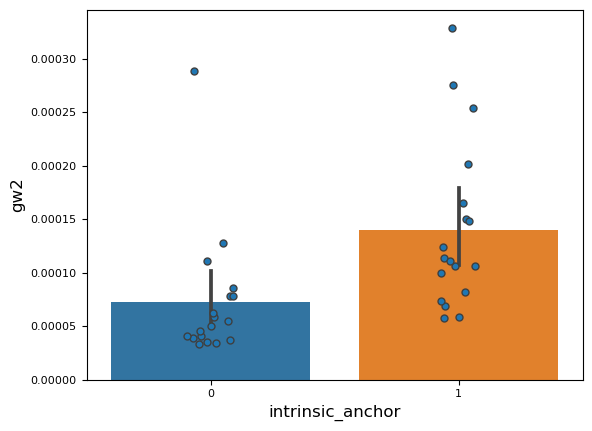

In [45]:
df_grp = df.groupby(['subject_id', 'intrinsic_anchor']).mean().reset_index()
sns.barplot(data=df_grp, x='intrinsic_anchor', y='gw2')
sns.stripplot(data=df_grp, x='intrinsic_anchor', y='gw2', linewidth=1)


In [46]:
from itertools import permutations

In [196]:
# compare each subject's joystick manifold with other subjects'
subjects_here = np.setdiff1d(SUB_IDS, ['avatarRT_sub_09','avatarRT_sub_20'])
btwn_subj_df = pd.DataFrame(columns = ['subject0', 'subject1', 'dist_intrinsic2intrinsic', 'dist_intrinsic2other'])
for (sub0, sub1) in permutations(subjects_here, 2):
    print(sub0, sub1)
    # get sub0's joystick manifold
    joy0 = squareform(pdist(prep_joystick_data(sub0)))
    joy1 = squareform(pdist(prep_joystick_data(sub1)))
    
    sub1ses2 = squareform(pdist(prep_rt_data(sub1, f'ses_02')))
    sub1ses3 = squareform(pdist(prep_rt_data(sub1, f'ses_03')))
    sub1ses4 = squareform(pdist(prep_rt_data(sub1, f'ses_04')))

    g0=ot.gromov.gromov_wasserstein2(joy0, joy1)
    g2=ot.gromov.gromov_wasserstein2(joy0, sub1ses2)
    g3=ot.gromov.gromov_wasserstein2(joy0, sub1ses3)
    g4=ot.gromov.gromov_wasserstein2(joy0, sub1ses4)
    btwn_subj_df.loc[len(btwn_subj_df)] = {'subject0': sub0, 'subject1':sub1, 'dist_intrinsic2intrinsic':g0, 'dist_intrinsic2other':np.mean([g2,g3,g4])}
    


avatarRT_sub_05 avatarRT_sub_06
loading in file
loading in file
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_06_ses_02_RT_20d_TPHATE_embedding.npy
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_06_ses_03_RT_20d_TPHATE_embedding.npy
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_06_ses_04_RT_20d_TPHATE_embedding.npy
avatarRT_sub_05 avatarRT_sub_07
loading in file
loading in file
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_07_ses_02_RT_20d_TPHATE_embedding.npy
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_07_ses_03_RT_20d_TPHATE_embedding.npy
loading in file /gpfs/milgram/scratch60/turk-browne/elb77/rtoffline//joystick_analyses/avatarRT_sub_07_ses_04_RT_20d_TPHATE_embedding.npy
avatarRT_sub_05 avatarRT_sub_08
loading in f

In [40]:
#btwn_subj_df.to_csv('btwn_subj_manifold_gwd2.csv')
btwn_subj_df = pd.read_csv('btwn_subj_manifold_gwd2.csv')

In [41]:
btwn_subj_df

,Unnamed: 0,subject0,subject1,dist_intrinsic2intrinsic,dist_intrinsic2other
0,0,avatarRT_sub_05,avatarRT_sub_06,0.000081,0.000129
1,1,avatarRT_sub_05,avatarRT_sub_07,0.000069,0.000078
2,2,avatarRT_sub_05,avatarRT_sub_08,0.000082,0.000090
3,3,avatarRT_sub_05,avatarRT_sub_10,0.000087,0.000107
4,4,avatarRT_sub_05,avatarRT_sub_11,0.000311,0.000105
...,...,...,...,...,...
301,301,avatarRT_sub_25,avatarRT_sub_19,0.000101,0.000167
302,302,avatarRT_sub_25,avatarRT_sub_21,0.000041,0.000136
303,303,avatarRT_sub_25,avatarRT_sub_22,0.000066,0.000133
304,304,avatarRT_sub_25,avatarRT_sub_23,0.000074,0.000085


In [77]:
self_df = df[(df['subject_id']==sub) & (df['intrinsic_anchor']==1)]
self_df[self_df['sesB']=='IM']['gw2'].item()

8.542246537375656e-05

In [42]:
btw0 = btwn_subj_df.groupby(['subject0']).mean()['dist_intrinsic2other'].values

In [47]:
wthn0 = df[df['intrinsic_anchor']==0].groupby(['subject_id']).mean()['gw2'].values

In [53]:
subjects_here = np.setdiff1d(SUB_IDS, ['avatarRT_sub_09','avatarRT_sub_20'])

rnd_df = pd.DataFrame(columns=['subject_id','self_dist_intrinsic2IMses_within','self_dist_intrinsic2others_within',
                               'zscore_dist_intrinsic2intrinsic_btwn', 'zscore_dist_intrinsic2others_btwn'])
tall_df = pd.DataFrame(columns=['subject_id','comparison','zscore'])
random_distrib = {}
for sub in subjects_here:
    self_df = df[(df['subject_id']==sub) & (df['intrinsic_anchor']==1)]
    othr_df = btwn_subj_df[(btwn_subj_df['subject0']==sub)]
    
    # compare intrinsic to IM session within self
    self_im = self_df[self_df['sesB']=='IM']['gw2'].item()
    
    # compare intrinsic to all others, mean
    self_others = np.min(self_df['gw2'].values)
    # create random distribution of others' values 
    
    # choose from intrinsic2intrinsic compariosn
    intrin2intrin = np.random.choice(np.concatenate([[self_others], othr_df['dist_intrinsic2intrinsic'].values], axis=0), 10000)
    # choose from intrinsic2other compariosn
    intrin2other = np.random.choice(np.concatenate([[self_others], othr_df['dist_intrinsic2other'].values], axis=0), 10000)
    # compare sub0's intrin2others_within with sub0's intrin2intrin_between subjects
    zs0 = (self_others - np.mean(intrin2intrin)) / np.std(intrin2intrin)
    # compare sub0's intrin2others_within with sub0's intrin2others_between subjects
    zs1 = (self_others - np.mean(intrin2other)) / np.std(intrin2other)
    rnd_df.loc[len(rnd_df)] = {'subject_id':sub, 'self_dist_intrinsic2IMses_within': self_im, 
                               'self_dist_intrinsic2others_within':self_others, 
                               'zscore_dist_intrinsic2intrinsic_btwn':zs0,
                              'zscore_dist_intrinsic2others_btwn':zs1}
    
    tall_df.loc[len(tall_df)] = {'subject_id':sub, 'comparison': 'intrinsic2intrinsic',
                               'zscore':zs0}
    tall_df.loc[len(tall_df)] = {'subject_id':sub, 'comparison': 'intrinsic2others',
                               'zscore':zs1}
    
    random_distrib[sub]=intrin2other

In [56]:
rnd_df.to_csv('results/results_public/gromov_wasserstein_analysis_results.csv')

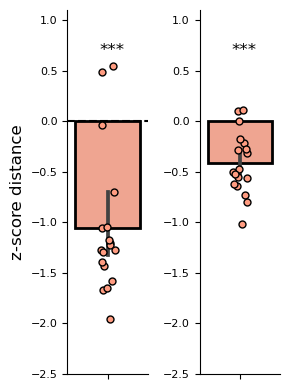

In [54]:
fig,ax=plt.subplots(1,2,figsize=(3,4), sharey=False)
c='#FF9C81'
a = np.array([rnd_df['zscore_dist_intrinsic2intrinsic_btwn'].values, np.zeros(18)])
b = np.array([rnd_df['zscore_dist_intrinsic2others_btwn'].values, np.zeros(18)])
s
_,p0,_=helper.permutation_test(a, 10000,alternative='two-sided')
_,p1,_=helper.permutation_test(b, 10000,alternative='two-sided')

order=['intrinsic2others','intrinsic2intrinsic']

sns.barplot(y=a[0],ax=ax[1] ,color=c,edgecolor='k',linewidth=2,alpha=1)
g=sns.stripplot( y=a[0],ax=ax[1] ,  color=c,edgecolor='k',linewidth=1,alpha=1)
g.set(title='', ylim=[-2.5,1.1],)

sns.barplot(y=b[0],ax=ax[0] , color=c,edgecolor='k',linewidth=2,alpha=1)
g=sns.stripplot( y=b[0],ax=ax[0] ,  color=c,edgecolor='k',linewidth=1,alpha=1)
g.set( ylabel='z-score distance')

ax[0].text(x=0-0.1, y=0.65, s=determine_symbol(p0), size=12) 
ax[1].text(x=0-0.1, y=0.65, s=determine_symbol(p1), size=12)

g.set(title=r'',  ylim=[-2.5, 1.1] )
g.axhline(0, color='k', ls='--')
sns.despine()
fig.tight_layout()
#plt.savefig('revision_plots/manifold_stability.pdf', format='pdf', transparent=True)




In [111]:
def bootstrap_ci(x, n_bootstrap=1000, ci=95, random_state=4, func=np.mean):
    n = len(x)
    rng = np.random.default_rng(random_state)
    boot = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        boot[i] = func(x[idx])
    lower = np.percentile(boot, (100 - ci) / 2)
    upper = np.percentile(boot, 100 - (100 - ci) / 2)
    mu=func(x)
    return np.mean(boot), (lower, upper) 